/tmp/ipykernel_14079/1426137011.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2018-01-01")
[*********************100%***********************]  1 of 1 completed


Data downloaded and saved.
Shape: (2093, 6)
Price             Close         High          Low         Open     Volume  \
Date                                                                        
2018-01-03  7671.100098  7689.899902  7640.500000  7648.100098  571662800   
2018-01-04  7695.899902  7702.500000  7671.100098  7671.100098  705864000   
2018-01-05  7724.200195  7727.700195  7689.799805  7695.899902  636035700   
2018-01-08  7696.500000  7733.399902  7691.799805  7724.200195  635135400   
2018-01-09  7731.000000  7733.100098  7696.500000  7696.500000  709674500   

Price       log_return  
Date                    
2018-01-03    0.003003  
2018-01-04    0.003228  
2018-01-05    0.003671  
2018-01-08   -0.003593  
2018-01-09    0.004473  
Dataset loaded: (2093, 6)
                  Close         High          Low         Open     Volume  \
Date                                                                        
2018-01-03  7671.100098  7689.899902  7640.500000  7648.10009

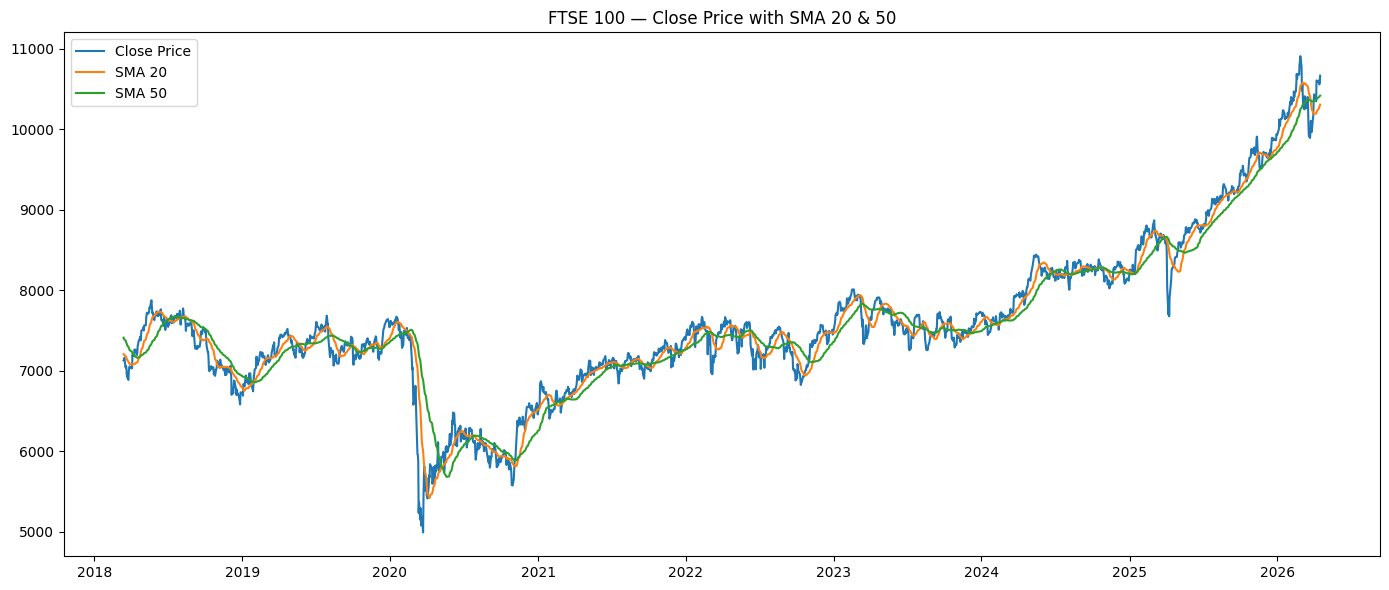

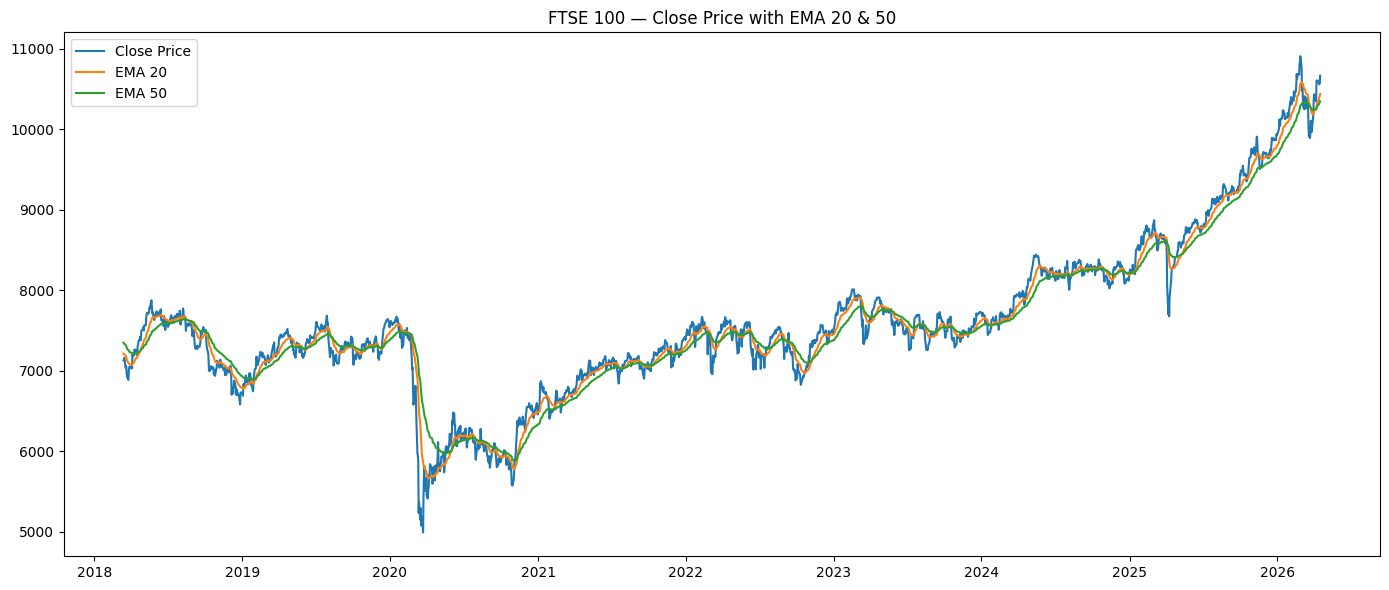

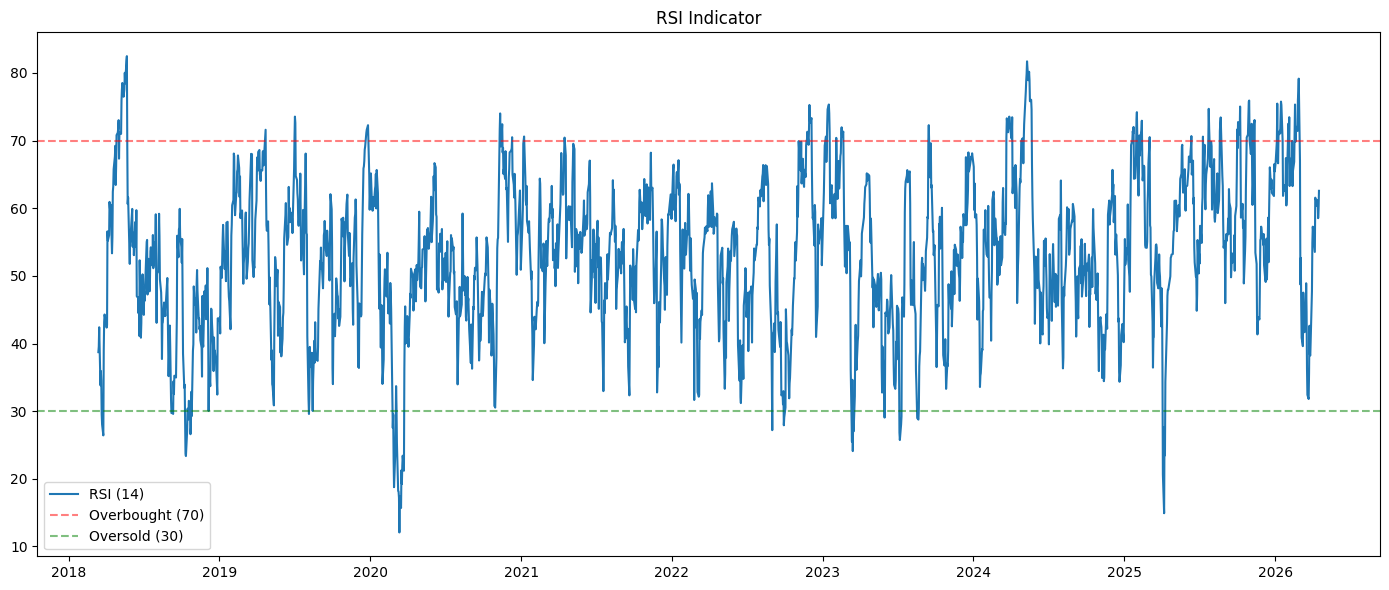

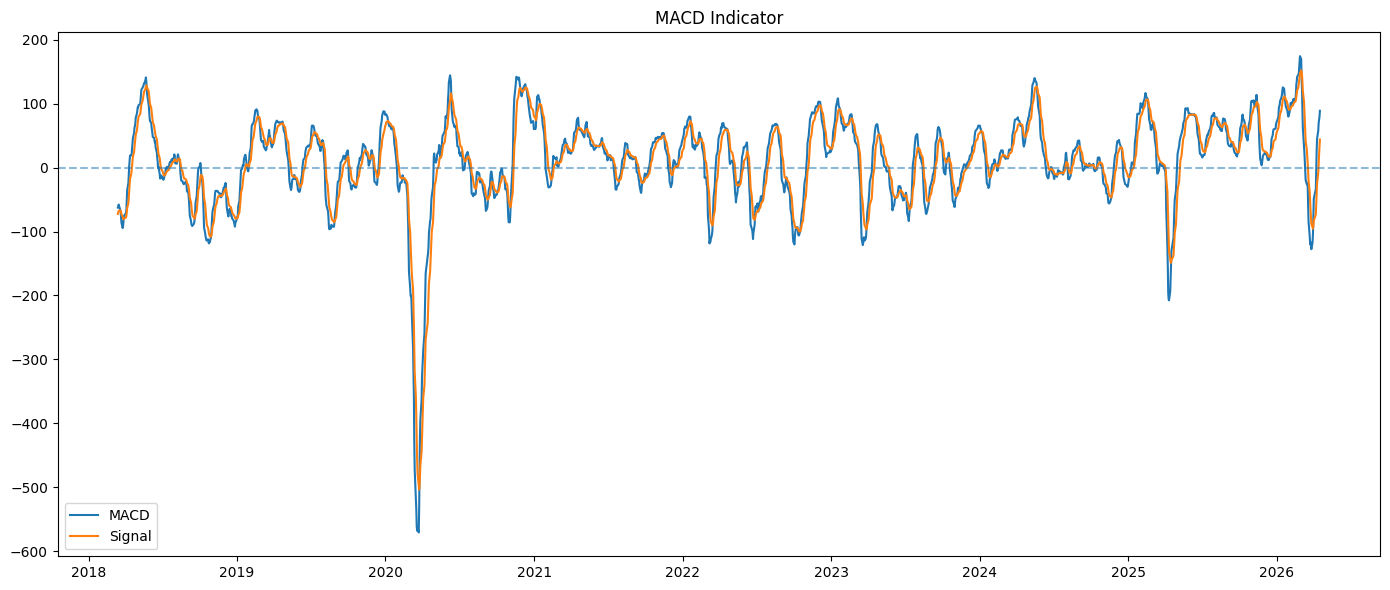

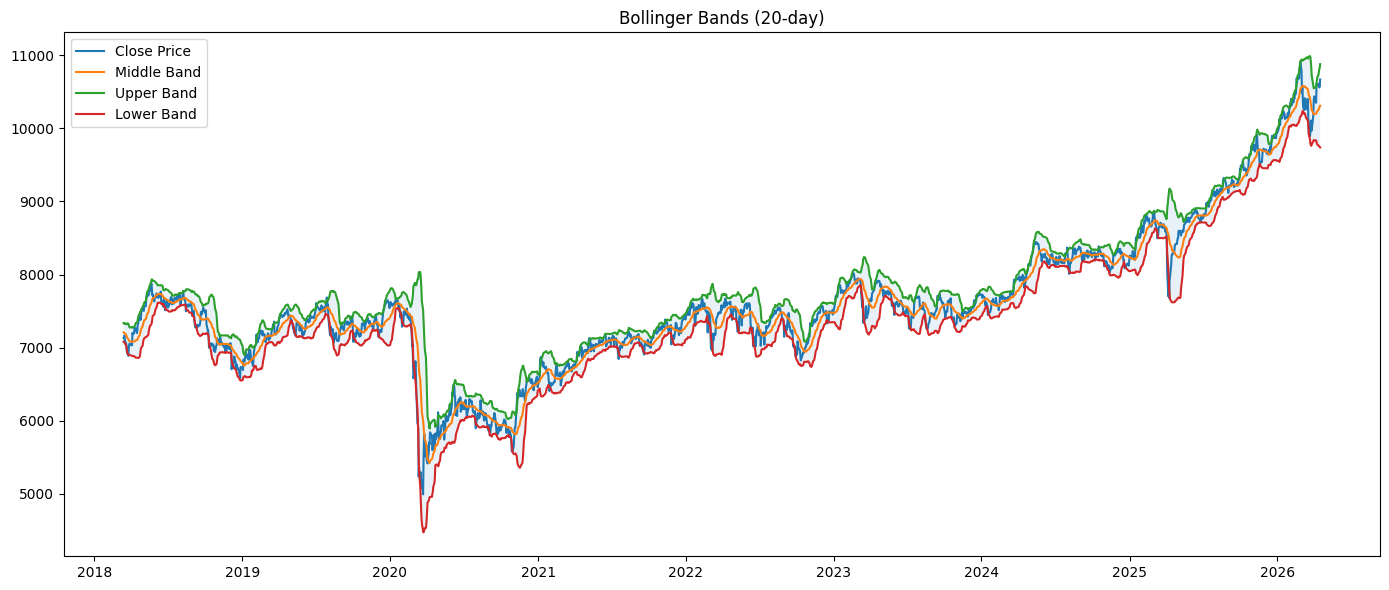

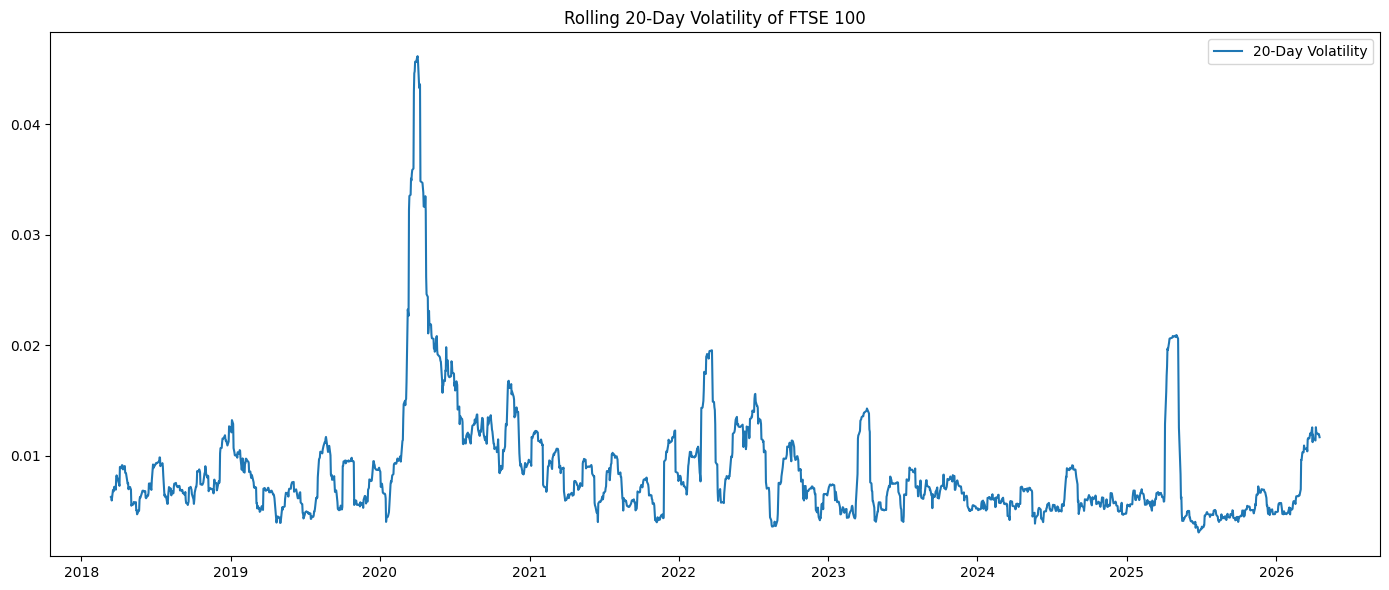

----- SUMMARY STATISTICS -----
count     2043.000000
mean      7600.035684
std        971.604799
min       4993.899902
25%       7110.000000
50%       7471.500000
75%       7950.100098
max      10910.599609
Name: Close, dtype: float64

Average Volatility: 0.008512362052624718

Biggest Daily Gain: 0.0866642461784119
Biggest Daily Loss: -0.1151170613425157

Up Days:   1101
Down Days: 942

SMA Crossover dates (first 10):
                  Close       SMA_20       SMA_50  Crossover
Date                                                        
2018-03-14  7132.700195  7209.324976  7413.661973        NaN
2018-04-24  7425.399902  7197.115015  7180.189990        2.0
2018-07-03  7593.299805  7640.344922  7641.361963       -2.0
2018-08-01  7652.899902  7663.114941  7660.159941        2.0
2018-08-28  7617.200195  7628.030005  7630.547969       -2.0
2019-01-30  6941.600098  6862.595020  6860.040020        2.0
2019-05-23  7231.000000  7319.500024  7332.715996       -2.0
2019-06-27  7402.299805  7346

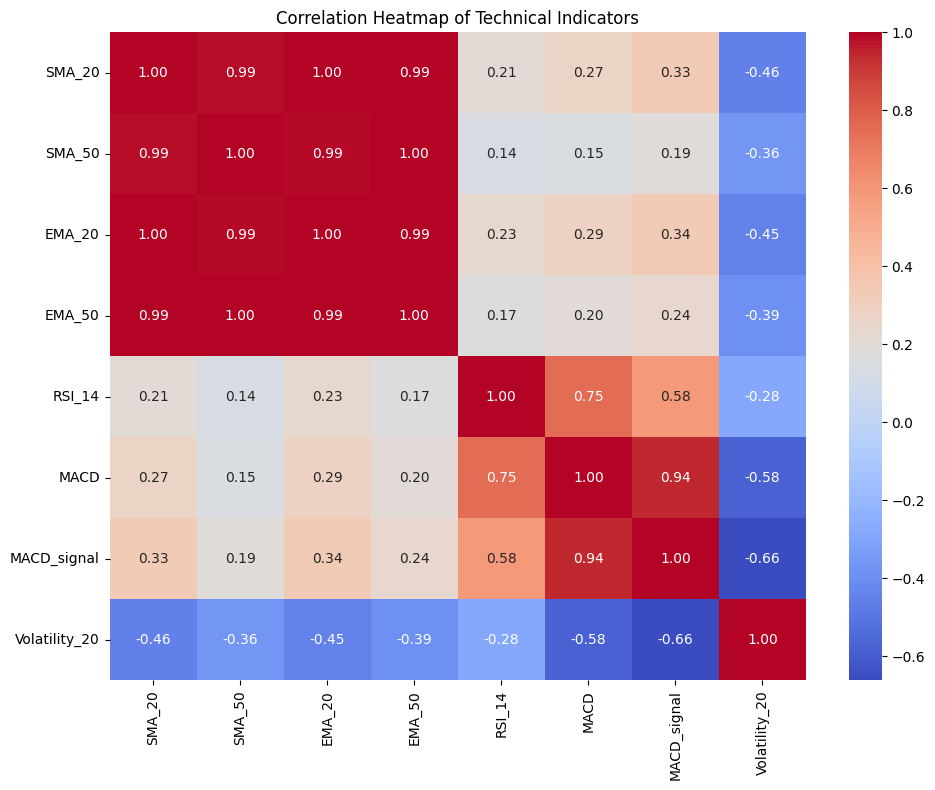


Logistic Regression
Accuracy: 0.4735812133072407
              precision    recall  f1-score   support

           0       0.45      0.87      0.59       226
           1       0.61      0.16      0.25       285

    accuracy                           0.47       511
   macro avg       0.53      0.51      0.42       511
weighted avg       0.54      0.47      0.40       511

Confusion Matrix:
 [[197  29]
 [240  45]]

Random Forest
Accuracy: 0.47162426614481406
              precision    recall  f1-score   support

           0       0.45      0.91      0.60       226
           1       0.64      0.12      0.21       285

    accuracy                           0.47       511
   macro avg       0.54      0.52      0.40       511
weighted avg       0.55      0.47      0.38       511

Confusion Matrix:
 [[206  20]
 [250  35]]

SVM
Accuracy: 0.5557729941291585
              precision    recall  f1-score   support

           0       0.50      0.34      0.40       226
           1       0.58 

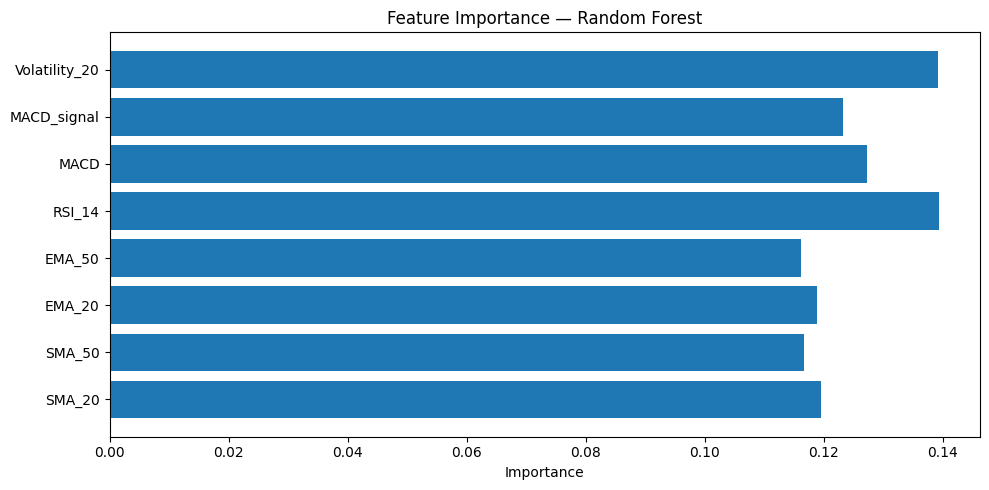

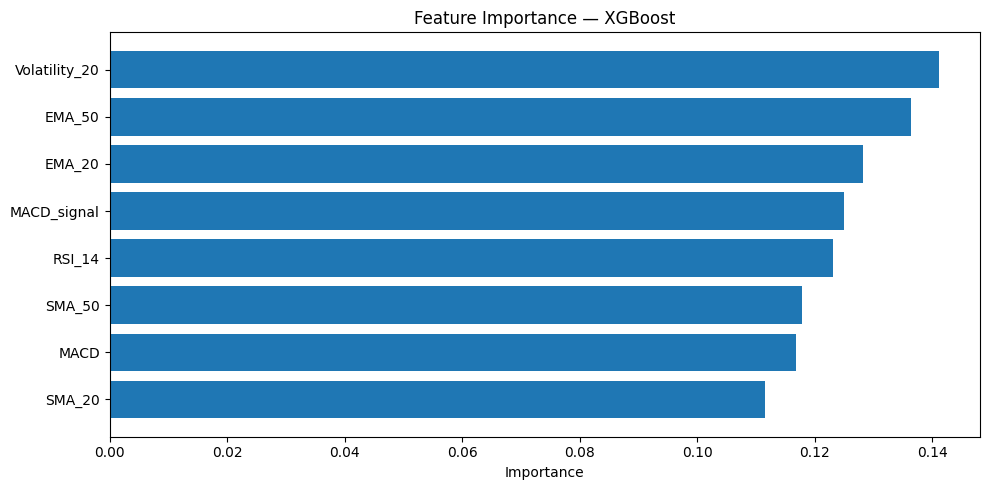

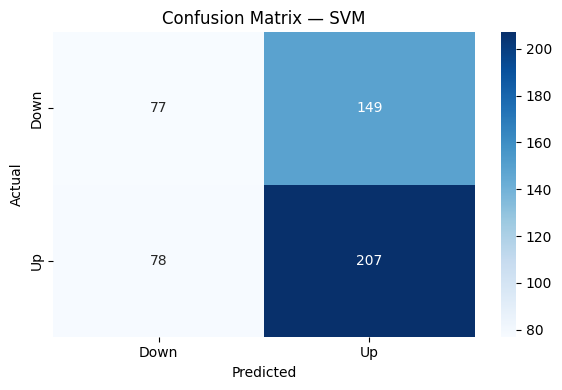

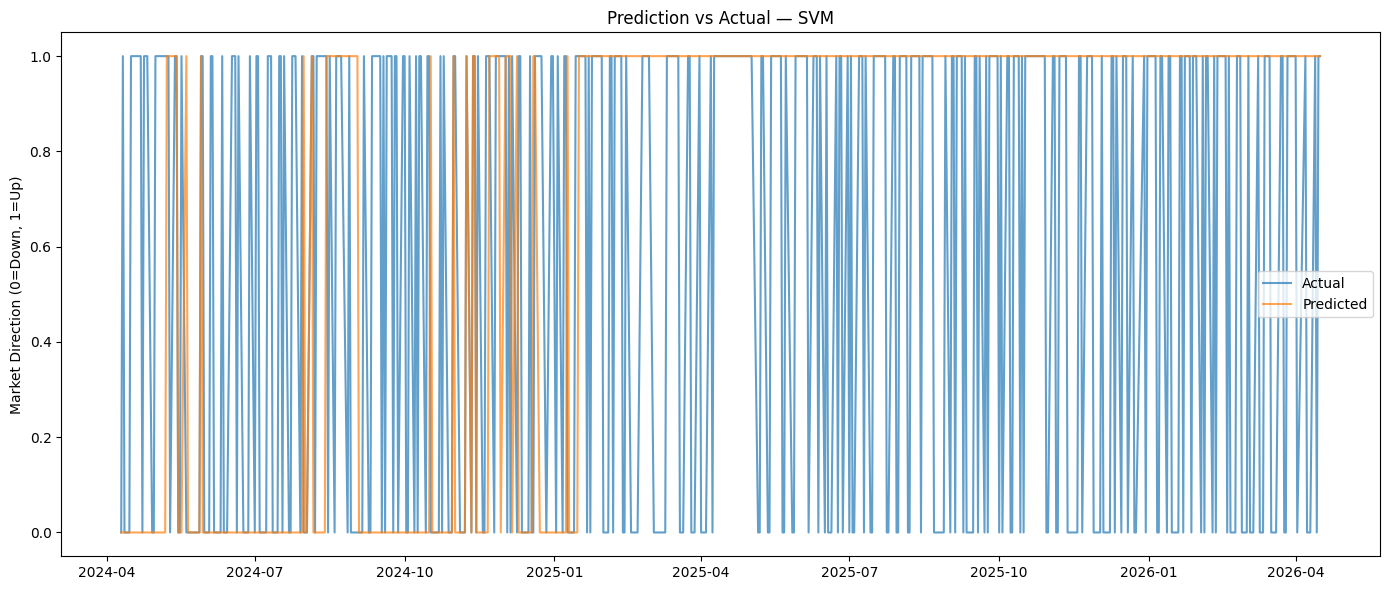


Done — final dataset saved to ftse100_final_dataset.csv


In [ ]:

# FTSE 100 Technical Analysis & ML Prediction - FIXED VERSION

#  Dependencies
# pip install yfinance pandas numpy matplotlib seaborn scikit-learn xgboost

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# SECTION 1 — Download & clean data

ticker = "^FTSE"
df = yf.download(ticker, start="2018-01-01")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.to_csv("ftse100_unc.csv")

df = df.dropna()
df.index = pd.to_datetime(df.index)
df = df.sort_index()

df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna()
df.to_csv("ftse100_clean.csv")

print("Data downloaded and saved.")
print("Shape:", df.shape)
print(df.head())


# SECTION 2 — Load clean data & compute technical indicators



df = pd.read_csv("ftse100_clean.csv", parse_dates=["Date"], index_col="Date")
print("Dataset loaded:", df.shape)
print(df.head())

# ── Simple Moving Averages
df["SMA_20"] = df["Close"].rolling(window=20).mean()
df["SMA_50"] = df["Close"].rolling(window=50).mean()

# ── Exponential Moving Averages ───
df["EMA_20"] = df["Close"].ewm(span=20, adjust=False).mean()
df["EMA_50"] = df["Close"].ewm(span=50, adjust=False).mean()

# ── RSI-14  ──
window_length = 14
delta = df["Close"].diff()
gain = np.where(delta > 0, delta, 0)
loss = np.where(delta < 0, -delta, 0)

avg_gain = pd.Series(gain, index=df.index).ewm(com=window_length - 1, adjust=False).mean()
avg_loss = pd.Series(loss, index=df.index).ewm(com=window_length - 1, adjust=False).mean()

rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

# ── MACD ──
df["EMA_12"] = df["Close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["Close"].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA_12"] - df["EMA_26"]
df["MACD_signal"] = df["MACD"].ewm(span=9, adjust=False).mean()

# ── Bollinger Bands ──
df["BB_Middle"] = df["Close"].rolling(window=20).mean()
df["BB_Std"]    = df["Close"].rolling(window=20).std()
df["BB_Upper"]  = df["BB_Middle"] + (df["BB_Std"] * 2)
df["BB_Lower"]  = df["BB_Middle"] - (df["BB_Std"] * 2)

# ── Rolling volatility ──
df["Volatility_20"] = df["log_return"].rolling(window=20).std()

# Trim rows before indicators are fully warmed up (largest window = 50)
if len(df) > 50:
    df = df.iloc[50:]

print("Final shape (after trimming):", df.shape)
df.to_csv("ftse100_with_indicators.csv")


# SECTION 3 — Plots

df = pd.read_csv("ftse100_with_indicators.csv", parse_dates=["Date"], index_col="Date")
print("Indicators file loaded:", df.shape)

# SMA
plt.figure(figsize=(14, 6))
plt.plot(df["Close"],   label="Close Price")
plt.plot(df["SMA_20"],  label="SMA 20")
plt.plot(df["SMA_50"],  label="SMA 50")
plt.title("FTSE 100 — Close Price with SMA 20 & 50")
plt.legend(); plt.tight_layout(); plt.show()

# EMA
plt.figure(figsize=(14, 6))
plt.plot(df["Close"],   label="Close Price")
plt.plot(df["EMA_20"],  label="EMA 20")
plt.plot(df["EMA_50"],  label="EMA 50")
plt.title("FTSE 100 — Close Price with EMA 20 & 50")
plt.legend(); plt.tight_layout(); plt.show()

# RSI
plt.figure(figsize=(14, 6))
plt.plot(df["RSI_14"], label="RSI (14)")
plt.axhline(70, linestyle="--", alpha=0.5, color="red",   label="Overbought (70)")
plt.axhline(30, linestyle="--", alpha=0.5, color="green", label="Oversold (30)")
plt.title("RSI Indicator")
plt.legend(); plt.tight_layout(); plt.show()

# MACD
plt.figure(figsize=(14, 6))
plt.plot(df["MACD"],        label="MACD")
plt.plot(df["MACD_signal"], label="Signal")
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("MACD Indicator")
plt.legend(); plt.tight_layout(); plt.show()

# Bollinger Bands
plt.figure(figsize=(14, 6))
plt.plot(df["Close"],     label="Close Price")
plt.plot(df["BB_Middle"], label="Middle Band")
plt.plot(df["BB_Upper"],  label="Upper Band")
plt.plot(df["BB_Lower"],  label="Lower Band")
plt.fill_between(df.index, df["BB_Lower"], df["BB_Upper"], alpha=0.1)
plt.title("Bollinger Bands (20-day)")
plt.legend(); plt.tight_layout(); plt.show()

# Volatility
plt.figure(figsize=(14, 6))
plt.plot(df["Volatility_20"], label="20-Day Volatility")
plt.title("Rolling 20-Day Volatility of FTSE 100")
plt.legend(); plt.tight_layout(); plt.show()


# SECTION 4 — Summary statistics & signals


print("----- SUMMARY STATISTICS -----")
print(df["Close"].describe())
print("\nAverage Volatility:", df["Volatility_20"].mean())
print("\nBiggest Daily Gain:", df["log_return"].max())
print("Biggest Daily Loss:", df["log_return"].min())

df["Up_Day"] = df["log_return"] > 0
print("\nUp Days:  ", df["Up_Day"].sum())
print("Down Days:", (~df["Up_Day"]).sum())

# SMA crossover signals
df["Signal"]    = np.where(df["SMA_20"] > df["SMA_50"], 1, -1)
df["Crossover"] = df["Signal"].diff()
cross = df[df["Crossover"] != 0][["Close", "SMA_20", "SMA_50", "Crossover"]]
print("\nSMA Crossover dates (first 10):")
print(cross.head(10))

# MACD crossover signals
df["MACD_Signal_Flag"] = np.where(df["MACD"] > df["MACD_signal"], 1, -1)
df["MACD_Crossover"]   = df["MACD_Signal_Flag"].diff()
print("\nMACD Crossover dates (first 10):")
print(df[df["MACD_Crossover"] != 0].head(10))

# RSI status
df["RSI_Status"] = np.where(df["RSI_14"] > 70, "Overbought",
                    np.where(df["RSI_14"] < 30, "Oversold", "Neutral"))
print("\nRSI Status counts:")
print(df["RSI_Status"].value_counts())

# Correlation heatmap
features = ["SMA_20", "SMA_50", "EMA_20", "EMA_50",
            "RSI_14", "MACD", "MACD_signal", "Volatility_20"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[features].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Technical Indicators")
plt.tight_layout(); plt.show()

df.to_csv("ftse100_with_indicators5.csv")


# SECTION 5 — ML Models


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

df["next_return"] = df["log_return"].shift(-1)
df["Target"] = np.where(df["next_return"] > 0, 1, 0)
df = df.dropna()

X = df[features]
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=False
)

# Model 1 — Logistic Regression (class_weight balanced to handle imbalance)
log_model = LogisticRegression(max_iter=500, class_weight="balanced")
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)

# Model 2 — Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Model 3 — SVM (requires scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

svm = SVC(kernel="rbf", C=1, gamma="scale", class_weight="balanced")
svm.fit(X_train_scaled, y_train)
svm_pred = svm.predict(X_test_scaled)

# Model 4 — XGBoost
xgb = XGBClassifier(
    n_estimators=200, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric="logloss", random_state=42
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

# ── Evaluation ─────
models = {
    "Logistic Regression": log_pred,
    "Random Forest":       rf_pred,
    "SVM":                 svm_pred,
    "XGBoost":             xgb_pred,
}

for name, pred in models.items():
    print(f"\n{'='*40}")
    print(f"{name}")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

# ── Feature importance ─
plt.figure(figsize=(10, 5))
plt.barh(features, rf.feature_importances_)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance")
plt.tight_layout(); plt.show()

importances_xgb = xgb.feature_importances_
indices_xgb = np.argsort(importances_xgb)
plt.figure(figsize=(10, 5))
plt.barh(np.array(features)[indices_xgb], importances_xgb[indices_xgb])
plt.xlabel("Importance")
plt.title("Feature Importance — XGBoost")
plt.tight_layout(); plt.show()

# ── Confusion matrix plot (SVM) ──
cm = confusion_matrix(y_test, svm_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Down", "Up"], yticklabels=["Down", "Up"])
plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.title("Confusion Matrix — SVM")
plt.tight_layout(); plt.show()

# ── Prediction vs Actual (SVM) ──
results = pd.DataFrame({"Actual": y_test.values, "Predicted": svm_pred},
                       index=y_test.index)
plt.figure(figsize=(14, 6))
plt.plot(results.index, results["Actual"],    label="Actual",    alpha=0.7)
plt.plot(results.index, results["Predicted"], label="Predicted", alpha=0.7)
plt.title("Prediction vs Actual — SVM")
plt.ylabel("Market Direction (0=Down, 1=Up)")
plt.legend(); plt.tight_layout(); plt.show()

# ── Save predictions ─
df.loc[X_test.index, "Logistic_Pred"] = log_pred
df.loc[X_test.index, "RF_Pred"]       = rf_pred
df.loc[X_test.index, "SVM_Pred"]      = svm_pred
df.loc[X_test.index, "XGB_Pred"]      = xgb_pred

df.to_csv("ftse100_final_dataset.csv")
print("\nDone — final dataset saved to ftse100_final_dataset.csv")